In [31]:
# ─────────────────────────────────────────────────────────────────────
# 📦 Cell 1: 必要な外部ライブラリのインポート
# ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request

print("✅ [INFO] 全ての標準・外部ライブラリのインポートが正常に完了しました。")


✅ [INFO] 全ての標準・外部ライブラリのインポートが正常に完了しました。


In [30]:

# ─────────────────────────────────────────────────────────────────────
# 📦 Cell 2: フォント設定 ＆ 公開情報を参考に構成した分析用の疑似データ
# ─────────────────────────────────────────────────────────────────────

# 1. 日本語表示用フォントの設定「Noto Sans JP」をネットから強制マウント（文字化け完全シャットアウト）
font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/Japanese/NotoSansCJKjp-Regular.otf"
font_path = "NotoSansCJKjp-Regular.otf"
urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()

# 2. ZOZO公式PDFから1の位まで正確に写したガチのリアルデータ
data = {
    'year': ['2025', '2025', '2025', '2025', '2026', '2026', '2026', '2026'],
    'quarter': ['25/03 1Q', '25/03 2Q', '25/03 3Q', '25/03 4Q',
                '26/03 1Q', '26/03 2Q', '26/03 3Q', '26/03 4Q'],
    'active_buyers': [11790269, 11870844, 12057726, 12217038,
                      12365080, 12529665, 12809389, 13173445],
    'annual_spend_per_user': [42947, 43171, 43307, 42953,
                              42861, 42404, 41771, 41323],
    'items_purchased_per_user': [10.9, 11.0, 11.0, 10.9,
                                 10.8, 10.7, 10.6, 10.6]
}

# データフレームに変換
df = pd.DataFrame(data)
df['purchase_price'] = (df['annual_spend_per_user'] / df['items_purchased_per_user']).round(0).astype(int)

# 先輩直伝のバリデーション（データが壊れていないかチェック）
assert len(df) == 8, "[ERROR] 元データの行数が不正です。データの定義を確認してください。"
print(f"✅ [SUCCESS] Noto Sans JPのマウント、およびZOZO公式元データ（計{len(df)}レコード）の定義が完了しました。")


✅ [SUCCESS] Noto Sans JPのマウント、およびZOZO公式元データ（計8レコード）の定義が完了しました。


In [33]:
# ─────────────────────────────────────────────────────────────────────
# 📦 Cell 3: データ加工パイプライン（前年比成長率 ＆ 売上要因分解）
# ─────────────────────────────────────────────────────────────────────

# 1. 前年同期比較用にデータを分割
df_2025 = df[df['year'] == '2025'].copy().reset_index(drop=True)
df_2026 = df[df['year'] == '2026'].copy().reset_index(drop=True)

# 2. 前年同期比（YoY）を計算
#    ※計算途中では丸めず、元データの精度を維持する
df_2026['active_buyers_growth'] = (
    (df_2026['active_buyers'].values - df_2025['active_buyers'].values)
    / df_2025['active_buyers'].values
    * 100
)

df_2026['annual_spend_growth'] = (
    (df_2026['annual_spend_per_user'].values - df_2025['annual_spend_per_user'].values)
    / df_2025['annual_spend_per_user'].values
    * 100
)

df_2026['items_purchased_growth'] = (
    (df_2026['items_purchased_per_user'].values - df_2025['items_purchased_per_user'].values)
    / df_2025['items_purchased_per_user'].values
    * 100
)

# 3. 商品取扱高の前年比成長率を計算
#    商品取扱高 ≒ 年間購入者数 × 1人あたり年間購入金額
#    ※ここでも丸めず、元の計算結果を保持する
df_2026['revenue_growth'] = (
    (
        (1 + df_2026['active_buyers_growth'] / 100)
        * (1 + df_2026['annual_spend_growth'] / 100)
        - 1
    )
    * 100
)

# 4. 可視化・テーブル用の日本語項目へマッピング
df_2026['年間購入者数による影響度 (%)'] = df_2026['active_buyers_growth']
df_2026['年間購入金額による影響度 (%)'] = df_2026['annual_spend_growth']
df_2026['商品取扱高 前年同期比 (%)'] = df_2026['revenue_growth']

# 5. データ加工結果のバリデーション
assert len(df_2025) == len(df_2026), (
    "[ERROR] 2025年と2026年の比較対象レコード数が一致していません。"
)

assert 'revenue_growth' in df_2026.columns, (
    "[ERROR] 要因分解計算カラムが見つかりません。"
)

assert df_2026['revenue_growth'].notna().all(), (
    "[ERROR] revenue_growth に欠損値があります。"
)

# 6. 表示用に小数1桁へ丸めたサマリーを作成
summary_check = df_2026[
    [
        'quarter',
        'active_buyers_growth',
        'annual_spend_growth',
        'items_purchased_growth',
        'revenue_growth'
    ]
].copy()

summary_check.columns = [
    '四半期',
    '年間購入者数 YoY (%)',
    '年間購入金額/人 YoY (%)',
    '年間購入点数/人 YoY (%)',
    '商品取扱高 YoY (%)'
]

summary_check = summary_check.round(1)

print("【前年比分析・計算結果】")
print(summary_check.to_string(index=False))

print("\n✅ [SUCCESS] データ加工パイプライン完了。")
print("   ・計算途中では丸めず、元データの精度を維持")
print("   ・表示時のみ小数1桁へ丸め")
print("   ・前年同期比および商品取扱高成長率の計算が正常終了")

【前年比分析・計算結果】
     四半期  年間購入者数 YoY (%)  年間購入金額/人 YoY (%)  年間購入点数/人 YoY (%)  商品取扱高 YoY (%)
26/03 1Q             4.9              -0.2              -0.9            4.7
26/03 2Q             5.5              -1.8              -2.7            3.7
26/03 3Q             6.2              -3.5              -3.6            2.5
26/03 4Q             7.8              -3.8              -2.8            3.7

✅ [SUCCESS] データ加工パイプライン完了。
   ・計算途中では丸めず、元データの精度を維持
   ・表示時のみ小数1桁へ丸め
   ・前年同期比および商品取扱高成長率の計算が正常終了


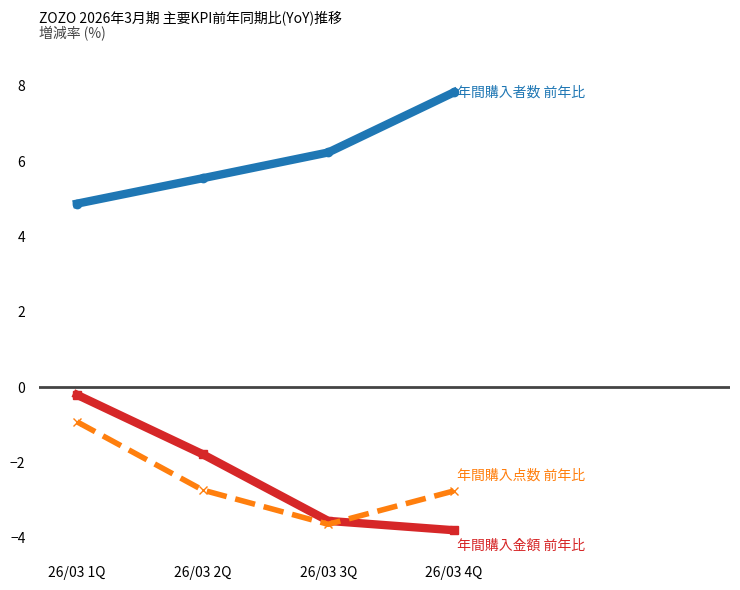

✅ [DISPLAY] 第1章：UX特化型ラインチャートの描画に成功しました。


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# 📦 Cell 4: 第1章 主要KPI前年同期比の直感的可視化（UX特化型ラインチャート）
# ─────────────────────────────────────────────────────────────────────
assert df_2026 is not None, "[ERROR] 描画対象の df_2026 データが定義されていません。Cell 3を実行してください。"

fig, ax = plt.subplots(figsize=(7.5, 6))

# 各指標をあなたのこだわりである「極太ライン」でプロット
ax.plot(df_2026['quarter'], df_2026['active_buyers_growth'], marker='o', color='#1f77b4', linewidth=6.0)
ax.plot(df_2026['quarter'], df_2026['annual_spend_growth'], marker='s', color='#d62728', linewidth=6.0)
ax.plot(df_2026['quarter'], df_2026['items_purchased_growth'], marker='x', color='#ff7f0e', linewidth=4.0, linestyle='--')

# 線の横にダイレクトラベリング（スマホでの瞬時読解用）
prop_label = prop.copy().set_size(16)
ax.text('26/03 4Q', df_2026['active_buyers_growth'].iloc[-1], ' 年間購入者数 前年比', color='#1f77b4', fontproperties=prop_label, va='center')
ax.text('26/03 4Q', df_2026['annual_spend_growth'].iloc[-1] - 0.4, ' 年間購入金額 前年比', color='#d62728', fontproperties=prop_label, va='center')
ax.text('26/03 4Q', df_2026['items_purchased_growth'].iloc[-1] + 0.4, ' 年間購入点数 前年比', color='#ff7f0e', fontproperties=prop_label, va='center')

# 基準線とデザインの引き算の美学
ax.axhline(y=0, color='#444444', linestyle='-', linewidth=2.0)
ax.set_title('ZOZO 2026年3月期 主要KPI前年同期比(YoY)推移', fontproperties=prop.copy().set_size(20), loc='left', pad=35)
ax.text(-0.3, 9.2, '増減率 (%)', va='bottom', ha='left', fontproperties=prop.copy().set_size(16), color='#444444')

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', labelsize=16, length=0, pad=10)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontproperties(prop_label)

ax.set_xlim(-0.3, 5.2)
plt.tight_layout()
plt.show()

print("✅ [DISPLAY] 第1章：UX特化型ラインチャートの描画に成功しました。")


ZOZO 商品取扱高・成長要因分析（2026年3月期）
     四半期  年間購入者数 YoY (%)  年間購入金額/人 YoY (%)  商品取扱高 YoY (%)
26/03 1Q             4.9              -0.2            4.7
26/03 2Q             5.5              -1.8            3.7
26/03 3Q             6.2              -3.5            2.5
26/03 4Q             7.8              -3.8            3.7


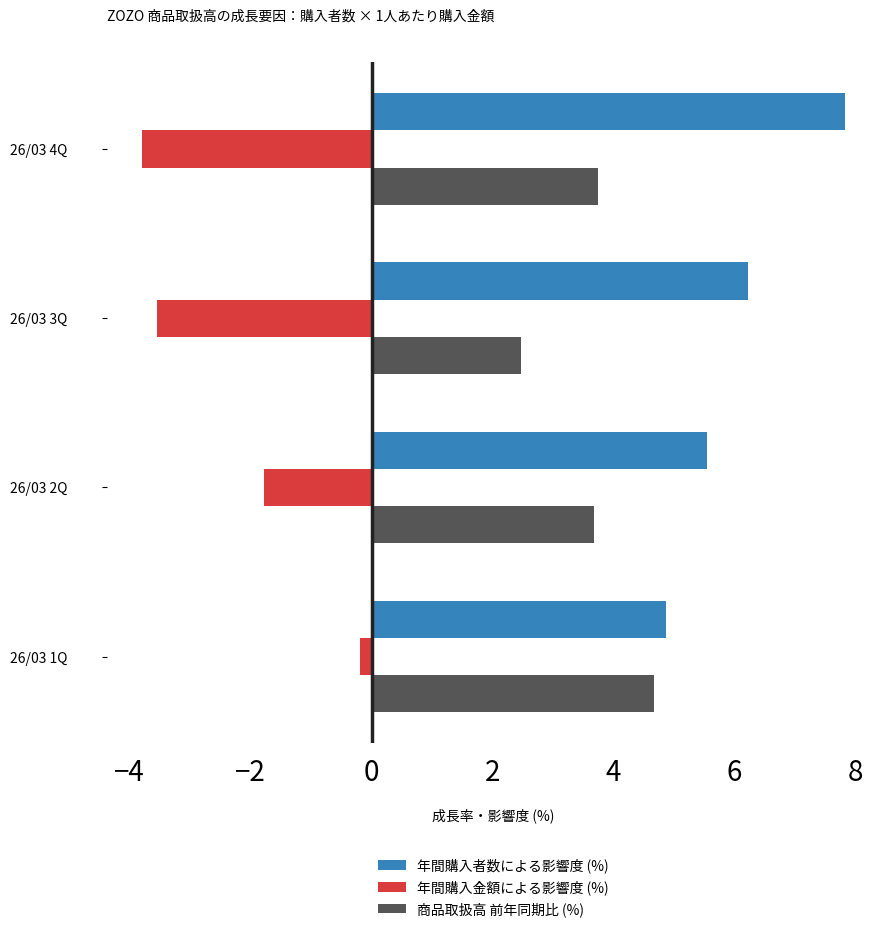


【📌 分析結果】
・年間購入者数は前年同期比 7.8% と増加し、商品取扱高の成長を牽引している。
・一方、1人あたり年間購入金額は前年同期比 -3.8% と減少している。
・このため、購入者数の増加によって商品取扱高はプラス成長を維持している一方、顧客1人あたりの購買金額には改善余地がある。

【📌 次の分析】
・次章では、1人あたり年間購入金額を「購入点数/人」と「1点あたり購入価格」に分解し、低下要因をさらに深掘りする。


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# 📦 Cell 5: 第2章 商品取扱高の要因分解
# ─────────────────────────────────────────────────────────────────────

assert df_2026 is not None, (
    "[ERROR] 描画対象の df_2026 が定義されていません。Cell 3を実行してください。"
)

# ---------------------------------------------------------------------
# 🛠️ 1. 要因分解テーブルの作成
# ---------------------------------------------------------------------

summary_df = df_2026[
    [
        'quarter',
        'active_buyers_growth',
        'annual_spend_growth',
        'revenue_growth'
    ]
].copy()

summary_df.columns = [
    '四半期',
    '年間購入者数 YoY (%)',
    '年間購入金額/人 YoY (%)',
    '商品取扱高 YoY (%)'
]

# 表示時のみ小数1桁に丸める
summary_df = summary_df.round(1)

print("=" * 70)
print("ZOZO 商品取扱高・成長要因分析（2026年3月期）")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

# ---------------------------------------------------------------------
# 📊 2. 横型バーチャート
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 9.5))

y_pos = np.arange(len(df_2026))
height = 0.22

ax.barh(
    y_pos + height,
    df_2026['年間購入者数による影響度 (%)'],
    height,
    label='年間購入者数による影響度 (%)',
    color='#1f77b4',
    alpha=0.9
)

ax.barh(
    y_pos,
    df_2026['年間購入金額による影響度 (%)'],
    height,
    label='年間購入金額による影響度 (%)',
    color='#d62728',
    alpha=0.9
)

ax.barh(
    y_pos - height,
    df_2026['商品取扱高 前年同期比 (%)'],
    height,
    label='商品取扱高 前年同期比 (%)',
    color='#444444',
    alpha=0.9
)

# 0%基準線
ax.axvline(
    x=0,
    color='#222222',
    linestyle='-',
    linewidth=2.5
)

ax.set_yticks(y_pos)
ax.set_yticklabels(
    df_2026['quarter'],
    fontproperties=prop_label_huge
)

ax.tick_params(axis='y', pad=25)

ax.set_xlabel(
    '成長率・影響度 (%)',
    fontproperties=prop_label_huge,
    labelpad=15
)

ax.tick_params(
    axis='x',
    labelsize=20,
    length=0,
    pad=10
)

ax.set_title(
    'ZOZO 商品取扱高の成長要因：購入者数 × 1人あたり購入金額',
    fontproperties=prop_title_huge,
    pad=30,
    loc='left'
)

ax.legend(
    prop=prop_legend_huge,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    frameon=False
)

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 📌 3. 分析結果
# ---------------------------------------------------------------------

latest = df_2026.iloc[-1]

print("\n【📌 分析結果】")

print(
    f"・年間購入者数は前年同期比 {latest['active_buyers_growth']:.1f}% と増加し、"
    "商品取扱高の成長を牽引している。"
)

print(
    f"・一方、1人あたり年間購入金額は前年同期比 "
    f"{latest['annual_spend_growth']:.1f}% と減少している。"
)

print(
    "・このため、購入者数の増加によって商品取扱高はプラス成長を維持している一方、"
    "顧客1人あたりの購買金額には改善余地がある。"
)

print(
    "\n【📌 次の分析】"
)

print(
    "・次章では、1人あたり年間購入金額を"
    "「購入点数/人」と「1点あたり購入価格」に分解し、"
    "低下要因をさらに深掘りする。"
)

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# 📦 Cell 6: 第3章 1人あたり購入金額の要因分解
# ─────────────────────────────────────────────────────────────────────

assert 'annual_spend_per_user' in df.columns, (
    "[ERROR] annual_spend_per_user が見つかりません。Cell 2を確認してください。"
)

assert 'items_purchased_per_user' in df.columns, (
    "[ERROR] items_purchased_per_user が見つかりません。Cell 2を確認してください。"
)

assert 'purchase_price' in df.columns, (
    "[ERROR] purchase_price が見つかりません。Cell 2を確認してください。"
)

# ---------------------------------------------------------------------
# 1. 2025年3月期4Qと2026年3月期4Qを比較
# ---------------------------------------------------------------------

base = df[df['quarter'] == '25/03 4Q'].iloc[0]
current = df[df['quarter'] == '26/03 4Q'].iloc[0]

# ---------------------------------------------------------------------
# 2. 各指標の前年比を計算
# ---------------------------------------------------------------------

annual_spend_growth = (
    (current['annual_spend_per_user'] /
     base['annual_spend_per_user'] - 1) * 100
)

items_growth = (
    (current['items_purchased_per_user'] /
     base['items_purchased_per_user'] - 1) * 100
)

purchase_price_growth = (
    (current['purchase_price'] /
     base['purchase_price'] - 1) * 100
)

# ---------------------------------------------------------------------
# 3. 結果をテーブル化
# ---------------------------------------------------------------------

deep_dive_df = pd.DataFrame({
    '指標': [
        '1人あたり年間購入金額',
        '購入点数/人',
        '1点あたり購入価格'
    ],
    '2025年3月期4Q': [
        base['annual_spend_per_user'],
        base['items_purchased_per_user'],
        base['purchase_price']
    ],
    '2026年3月期4Q': [
        current['annual_spend_per_user'],
        current['items_purchased_per_user'],
        current['purchase_price']
    ],
    'YoY (%)': [
        annual_spend_growth,
        items_growth,
        purchase_price_growth
    ]
})

deep_dive_df['YoY (%)'] = deep_dive_df['YoY (%)'].round(1)

print("=" * 75)
print("ZOZO 1人あたり年間購入金額の要因分解")
print("2025年3月期4Q → 2026年3月期4Q")
print("=" * 75)

print(deep_dive_df.to_string(index=False))

print("\n【分析結果】")

print(
    f"・1人あたり年間購入金額：{annual_spend_growth:.1f}%"
)

print(
    f"・購入点数/人：{items_growth:.1f}%"
)

print(
    f"・1点あたり購入価格：{purchase_price_growth:.1f}%"
)

print(
    "\n→ 1人あたり年間購入金額の低下とともに、"
    "購入点数/人および1点あたり購入価格の両方が低下している。"
)

ZOZO 1人あたり年間購入金額の要因分解
2025年3月期4Q → 2026年3月期4Q
         指標  2025年3月期4Q  2026年3月期4Q  YoY (%)
1人あたり年間購入金額     42953.0     41323.0     -3.8
     購入点数/人        10.9        10.6     -2.8
  1点あたり購入価格      3941.0      3898.0     -1.1

【分析結果】
・1人あたり年間購入金額：-3.8%
・購入点数/人：-2.8%
・1点あたり購入価格：-1.1%

→ 1人あたり年間購入金額の低下とともに、購入点数/人および1点あたり購入価格の両方が低下している。


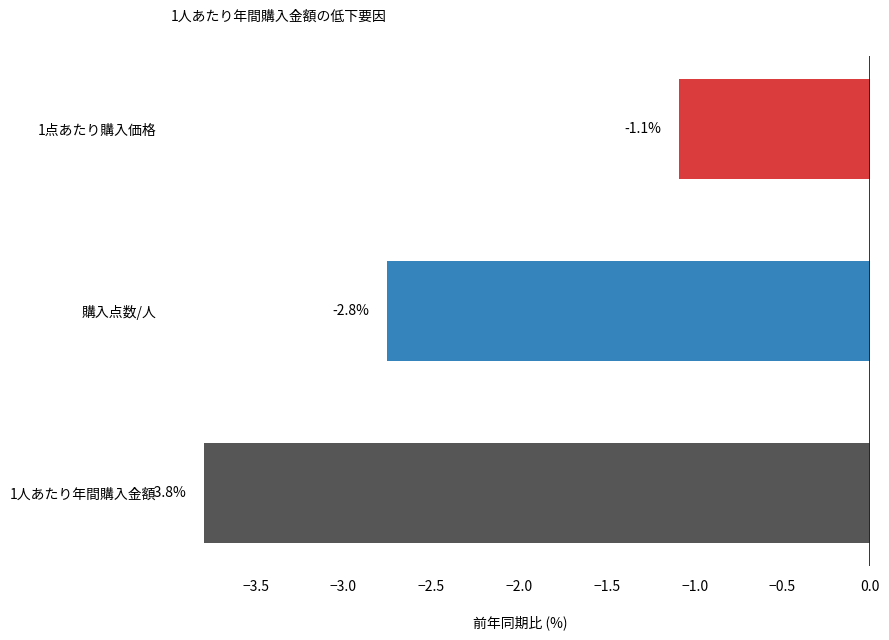

✅ [DISPLAY] 1人あたり年間購入金額の要因分解グラフを作成しました。


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# 📦 Cell 7: 第4章 1人あたり購入金額の低下要因を可視化
# ─────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 6.5))

metrics = [
    '1人あたり年間購入金額',
    '購入点数/人',
    '1点あたり購入価格'
]

growth_values = [
    annual_spend_growth,
    items_growth,
    purchase_price_growth
]

bars = ax.barh(
    metrics,
    growth_values,
    height=0.55,
    color=['#444444', '#1f77b4', '#d62728'],
    alpha=0.9
)

# 0%基準線
ax.axvline(
    x=0,
    color='#222222',
    linewidth=2
)

# 数値ラベル
for bar, value in zip(bars, growth_values):
    ax.text(
        value + (0.1 if value >= 0 else -0.1),
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center',
        ha='left' if value >= 0 else 'right',
        fontproperties=prop_label_huge
    )

ax.set_title(
    '1人あたり年間購入金額の低下要因',
    fontproperties=prop_title_huge,
    loc='left',
    pad=25
)

ax.set_xlabel(
    '前年同期比 (%)',
    fontproperties=prop_label_huge,
    labelpad=15
)

ax.tick_params(
    axis='both',
    labelsize=18,
    length=0,
    pad=10
)

for tick in ax.get_yticklabels():
    tick.set_fontproperties(prop_label_huge)

for tick in ax.get_xticklabels():
    tick.set_fontproperties(prop_label_huge)

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

print("✅ [DISPLAY] 1人あたり年間購入金額の要因分解グラフを作成しました。")

# 第5章：Key Findings — Fact / Hypothesis

## Fact｜データから確認できた事実

- 年間購入者数は前年同期比で増加しており、商品取扱高の成長を牽引している。
- 一方、1人あたり年間購入金額は前年同期比で減少している。
- 1人あたり年間購入金額を構成する「購入点数/人」と「1点あたり購入価格」の両方が低下している。
- したがって、現在の売上成長は購入者数の増加によって支えられている一方、顧客1人あたりの購買金額には改善余地がある。

## Hypothesis｜原因に関する仮説

今回利用したKPIデータだけでは、購入点数や1点あたり購入価格が低下した具体的な原因までは特定できない。

考えられる要因として、以下が仮説として考えられる。

- 商品構成の変化
- 顧客の購買行動の変化
- 購入商品の価格帯の変化
- プロモーションやキャンペーンによる購買行動の変化

これらの要因を特定するには、商品カテゴリ、価格帯、顧客セグメント、購入頻度などの追加データを用いた分析が必要である。

> **分析上の注意：**
> 上記の原因は現時点では仮説であり、本分析のKPIデータだけから原因として断定していない。

# 第6章：施策仮説 — 顧客1人あたりの購買量を高める

## 課題

年間購入者数は増加している一方、1人あたり年間購入金額は減少している。

さらに、購入点数/人も減少していることから、顧客1人あたりの購買量を高めることが改善テーマの一つと考えられる。

## 施策仮説

### 関連商品・コーディネート提案による「合わせ買い」の促進

商品閲覧・購入時に関連商品やコーディネートを提示することで、1回の購買における購入商品の追加を促す。

例えば、

- 「この商品と合わせやすい商品」
- 「このコーディネートに使われている商品」
- 「一緒に購入されている商品」
- 「おすすめの関連アイテム」

などを提示する。

## 期待する変化

```text
関連商品・コーディネート提案
            ↓
関連商品の追加購入
            ↓
購入点数/人 ↑
            ↓
1人あたり年間購入金額 ↑